# Build Target Variable

Before building a model we need to define what **career success** means.

This notebook computes several candidate targets and shows the top 10 players for each,
so we can judge intuitively which definition best captures what we want to predict.

### Candidates
| # | Target | Type |
|---|---|---|
| A | Career Points Per Game (PPG) | Regression |
| B | Career Games Played | Regression |
| C | Career Win-Share Proxy (PPG × seasons) | Regression |
| D | All-Star / Top-75 flag | Classification |
| E | Composite Score (PPG + RPG + APG, normalized) | Regression |

In [7]:
import sqlite3
import pandas as pd

DB_PATH = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\nba.sqlite"
CAREER_STATS_PATH = r"E:\Github\PS-Acq-Claude-Code-Test\jeff-NBA-model\player_career_stats.csv"

conn = sqlite3.connect(DB_PATH)
career = pd.read_csv(CAREER_STATS_PATH)
print(f"Career stats loaded: {len(career)} players")
career.head(3)

Career stats loaded: 1198 players


,player_id,player_name,seasons_played,games_played,fgm,rebounds,assists,steals,blocks,turnovers
0,101106,Andrew Bogut,14,693,2785,5828,1503,432,1046,1161
1,101107,Marvin Williams,14,974,3522,5122,1238,758,528,919
2,101108,Chris Paul,18,1207,7774,5537,11422,2535,199,2979


## Step 1 — Compute Points from Play-by-Play

The career stats CSV only has FGM. We need to split into 2PT and 3PT, and also get free throws made (FTM), to compute true points.

- **3PM:** eventmsgtype = 1, description contains '3PT'
- **FTM:** eventmsgtype = 3, description does NOT contain 'MISS'
- **2PM:** FGM − 3PM
- **Points:** 2×2PM + 3×3PM + FTM

In [8]:
# Valid players (drafted 2000+) — same filter as build_player_stats
conn.execute("DROP TABLE IF EXISTS temp_valid_players")
conn.execute("""
    CREATE TEMPORARY TABLE temp_valid_players AS
    SELECT DISTINCT person_id AS player_id
    FROM draft_history
    WHERE season >= 2000
""")
conn.commit()

In [9]:
# 3-pointers made: eventmsgtype=1 and description contains '3PT'
three_pm = pd.read_sql_query("""
    SELECT
        p.player1_id AS player_id,
        COUNT(*) AS three_pm
    FROM play_by_play p
    JOIN temp_valid_players v ON p.player1_id = v.player_id
    WHERE p.eventmsgtype = 1
      AND (
          p.homedescription LIKE '%3PT%'
          OR p.visitordescription LIKE '%3PT%'
      )
    GROUP BY p.player1_id
""", conn)

print(f"Players with 3PM data: {len(three_pm)}")
three_pm.head()

Players with 3PM data: 1005


,player_id,three_pm
0,101106,2
1,101107,954
2,101108,1709
3,101109,773
4,101110,613


In [10]:
# Free throws made: eventmsgtype=3, description does NOT contain 'MISS'
ftm = pd.read_sql_query("""
    SELECT
        p.player1_id AS player_id,
        COUNT(*) AS ftm
    FROM play_by_play p
    JOIN temp_valid_players v ON p.player1_id = v.player_id
    WHERE p.eventmsgtype = 3
      AND p.player1_id IS NOT NULL
      AND p.player1_id != 0
      AND (
          (p.homedescription IS NOT NULL AND p.homedescription NOT LIKE '%MISS%')
          OR (p.visitordescription IS NOT NULL AND p.visitordescription NOT LIKE '%MISS%')
      )
    GROUP BY p.player1_id
""", conn)

print(f"Players with FTM data: {len(ftm)}")
ftm.head()

Players with FTM data: 1173


,player_id,ftm
0,101106,745
1,101107,1864
2,101108,4525
3,101109,1465
4,101110,680


In [11]:
# Merge into career stats and compute points
# Cast player_id to int64 in SQL results to match career CSV
three_pm['player_id'] = three_pm['player_id'].astype('int64')
ftm['player_id'] = ftm['player_id'].astype('int64')

df = career.merge(three_pm, on='player_id', how='left')
df = df.merge(ftm, on='player_id', how='left')
df[['three_pm', 'ftm']] = df[['three_pm', 'ftm']].fillna(0).astype(int)

df['two_pm']     = df['fgm'] - df['three_pm']
df['total_pts']  = 2 * df['two_pm'] + 3 * df['three_pm'] + df['ftm']

print(f"Players: {len(df)}")
df[['player_name', 'games_played', 'fgm', 'three_pm', 'ftm', 'total_pts']].head(10)

Players: 1198


,player_name,games_played,fgm,three_pm,ftm,total_pts
0,Andrew Bogut,693,2785,2,745,6317
1,Marvin Williams,974,3522,954,1864,9862
2,Chris Paul,1207,7774,1709,4525,21782
3,Raymond Felton,857,3494,773,1465,9226
4,Martell Webster,480,1340,613,680,3973
5,Charlie Villanueva,539,2224,559,699,5706
6,Channing Frye,876,2817,1064,823,7521
7,Ike Diogu,193,421,1,316,1159
8,Deron Williams,774,4405,1051,2600,12461
9,Andrew Bynum,435,1996,1,1017,5010


## Step 2 — Compute All Target Candidates

We require a minimum of **100 games played** to filter out players with tiny sample sizes.

In [12]:
MIN_GAMES = 100
df_q = df[df['games_played'] >= MIN_GAMES].copy()
print(f"Players with {MIN_GAMES}+ games: {len(df_q)}")

# --- Target A: Career PPG ---
df_q['target_ppg'] = (df_q['total_pts'] / df_q['games_played']).round(1)

# --- Target B: Career Games Played ---
df_q['target_games'] = df_q['games_played']

# --- Target C: Win-Share Proxy (PPG x seasons) ---
df_q['target_ws_proxy'] = (df_q['target_ppg'] * df_q['seasons_played']).round(1)

# --- Target D: All-Star / Top-75 flag (from common_player_info) ---
players_info = pd.read_sql_query("""
    SELECT person_id AS player_id, greatest_75_flag
    FROM common_player_info
    WHERE draft_year >= 2000
""", conn)
players_info['player_id'] = players_info['player_id'].astype('int64')
df_q = df_q.merge(players_info, on='player_id', how='left')
df_q['target_top75'] = (df_q['greatest_75_flag'] == 'Y').astype(int)

# --- Target E: Composite Score (PPG + RPG + APG, z-score normalized) ---
df_q['rpg'] = (df_q['rebounds'] / df_q['games_played']).round(2)
df_q['apg'] = (df_q['assists']  / df_q['games_played']).round(2)

for col in ['target_ppg', 'rpg', 'apg']:
    df_q[f'{col}_z'] = (df_q[col] - df_q[col].mean()) / df_q[col].std()

df_q['target_composite'] = (df_q['target_ppg_z'] + df_q['rpg_z'] + df_q['apg_z']).round(2)

print("Targets computed.")

Players with 100+ games: 778
Targets computed.


## Step 3 — Top 10 for Each Target

The name recognition test: do the top 10 look right for what we're trying to predict?

In [13]:
# Target A — Career PPG
print("=== TARGET A: Career Points Per Game ===")
df_q.nlargest(10, 'target_ppg')[['player_name', 'games_played', 'seasons_played', 'target_ppg']]

=== TARGET A: Career Points Per Game ===


,player_name,games_played,seasons_played,target_ppg
192,Luka Doncic,337,5,27.7
319,Kevin Durant,1018,15,27.7
711,LeBron James,1463,20,27.7
613,Joel Embiid,424,7,26.8
507,Damian Lillard,724,10,26.0
200,Zion Williamson,108,3,25.3
397,Stephen Curry,904,14,25.3
502,Anthony Davis,635,10,25.3
120,Donovan Mitchell,423,6,25.2
190,Trae Young,362,5,25.1


In [14]:
# Target B — Career Games Played
print("=== TARGET B: Career Games Played ===")
df_q.nlargest(10, 'target_games')[['player_name', 'games_played', 'seasons_played', 'target_ppg']]

=== TARGET B: Career Games Played ===


,player_name,games_played,seasons_played,target_ppg
711,LeBron James,1463,20,27.7
670,Tony Parker,1271,18,15.7
755,Andre Iguodala,1241,19,10.8
582,Jamal Crawford,1226,20,14.5
2,Chris Paul,1207,18,18.0
656,Joe Johnson,1202,18,15.8
747,Dwight Howard,1202,18,15.6
746,Kyle Korver,1199,17,9.6
713,Carmelo Anthony,1195,19,22.3
649,Pau Gasol,1194,18,16.9


In [15]:
# Target C — Win-Share Proxy
print("=== TARGET C: Win-Share Proxy (PPG x Seasons) ===")
df_q.nlargest(10, 'target_ws_proxy')[['player_name', 'games_played', 'seasons_played', 'target_ppg', 'target_ws_proxy']]

=== TARGET C: Win-Share Proxy (PPG x Seasons) ===


,player_name,games_played,seasons_played,target_ppg,target_ws_proxy
711,LeBron James,1463,20,27.7,554.0
713,Carmelo Anthony,1195,19,22.3,423.7
319,Kevin Durant,1018,15,27.7,415.5
397,Stephen Curry,904,14,25.3,354.2
715,Dwyane Wade,1059,16,21.9,350.4
355,Russell Westbrook,1055,15,22.7,340.5
393,James Harden,1038,14,24.2,338.8
2,Chris Paul,1207,18,18.0,324.0
649,Pau Gasol,1194,18,16.9,304.2
286,LaMarcus Aldridge,1013,16,19.0,304.0


In [16]:
# Target D — Top 75 flag
print("=== TARGET D: Greatest 75 Flag ===")
top75 = df_q[df_q['target_top75'] == 1][['player_name', 'games_played', 'seasons_played', 'target_ppg']]
print(f"Players flagged as Top-75: {len(top75)}")
top75.sort_values('target_ppg', ascending=False).head(10)

=== TARGET D: Greatest 75 Flag ===
Players flagged as Top-75: 9


,player_name,games_played,seasons_played,target_ppg
319,Kevin Durant,1018,15,27.7
507,Damian Lillard,724,10,26.0
397,Stephen Curry,904,14,25.3
502,Anthony Davis,635,10,25.3
393,James Harden,1038,14,24.2
572,Giannis Antetokounmpo,768,10,23.2
355,Russell Westbrook,1055,15,22.7
715,Dwyane Wade,1059,16,21.9
2,Chris Paul,1207,18,18.0


In [17]:
# Target E — Composite Score
print("=== TARGET E: Composite Score (PPG + RPG + APG normalized) ===")
df_q.nlargest(10, 'target_composite')[['player_name', 'games_played', 'seasons_played', 'target_ppg', 'rpg', 'apg', 'target_composite']]

=== TARGET E: Composite Score (PPG + RPG + APG normalized) ===


,player_name,games_played,seasons_played,target_ppg,rpg,apg,target_composite
192,Luka Doncic,337,5,27.7,8.59,8.06,9.99
711,LeBron James,1463,20,27.7,7.87,7.42,9.23
355,Russell Westbrook,1055,15,22.7,7.41,8.40,8.58
620,Nikola Jokic,629,8,20.5,10.50,6.61,8.52
613,Joel Embiid,424,7,26.8,11.14,3.26,8.01
190,Trae Young,362,5,25.1,3.56,9.21,7.68
572,Giannis Antetokounmpo,768,10,23.2,9.82,4.75,7.56
393,James Harden,1038,14,24.2,5.74,7.06,7.21
49,Karl-Anthony Towns,506,8,22.7,11.06,3.14,7.04
502,Anthony Davis,635,10,25.3,10.59,2.48,6.93


## Step 4 — Distribution of Each Target

Check for skew, outliers, or heavy class imbalance before committing to a target.

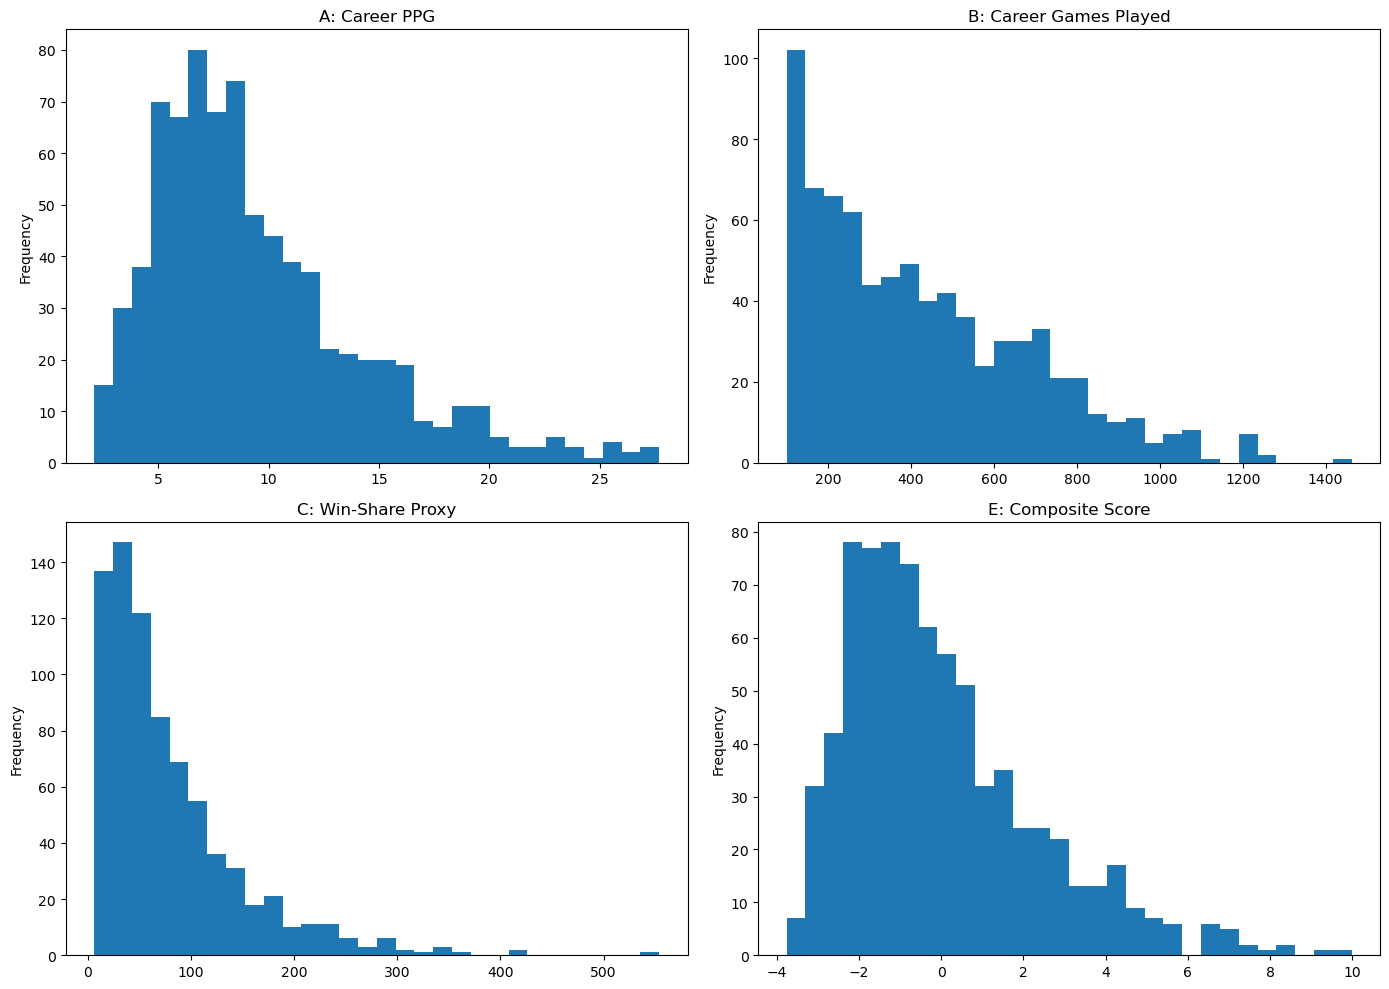


Target D — Top 75 class balance:
target_top75
0    769
1      9
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_q['target_ppg'].plot(kind='hist', bins=30, ax=axes[0,0], title='A: Career PPG')
df_q['target_games'].plot(kind='hist', bins=30, ax=axes[0,1], title='B: Career Games Played')
df_q['target_ws_proxy'].plot(kind='hist', bins=30, ax=axes[1,0], title='C: Win-Share Proxy')
df_q['target_composite'].plot(kind='hist', bins=30, ax=axes[1,1], title='E: Composite Score')

plt.tight_layout()
plt.show()

print("\nTarget D — Top 75 class balance:")
print(df_q['target_top75'].value_counts())